In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

df = X.copy()
df["target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
df.shape

(150, 5)

In [5]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [6]:
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [7]:
X = df.drop("target", axis=1)
y = df["target"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [10]:
model = DecisionTreeClassifier(
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [11]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [12]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.9333333333333333


In [13]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [14]:
cm = confusion_matrix(y_test, y_test_pred)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


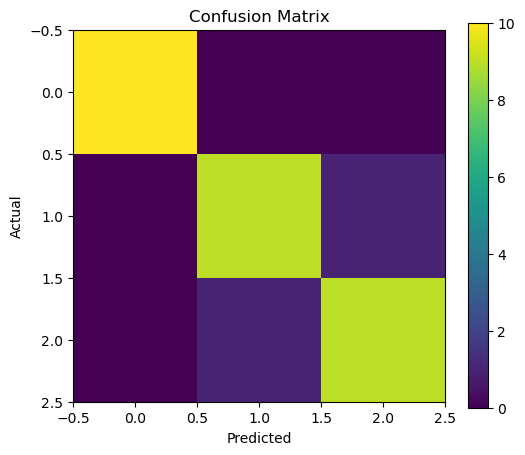

In [15]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

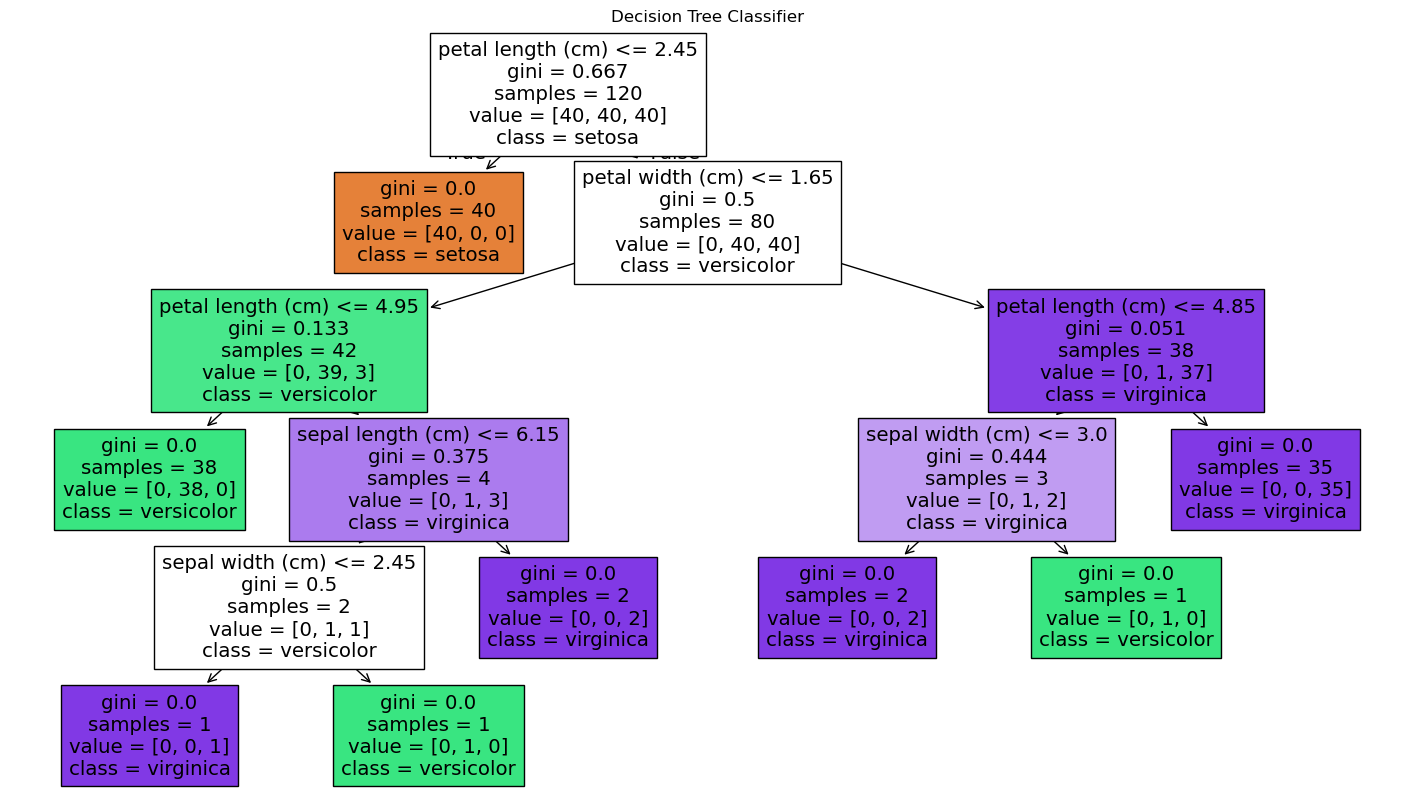

In [16]:
plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.title("Decision Tree Classifier")
plt.show()

In [17]:
depths = range(1, 11)

train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    tree.fit(X_train, y_train)
    
    train_scores.append(
        tree.score(X_train, y_train)
    )
    
    test_scores.append(
        tree.score(X_test, y_test)
    )

In [18]:
results = pd.DataFrame({
    "max_depth": depths,
    "training_accuracy": train_scores,
    "testing_accuracy": test_scores
})

results

,max_depth,training_accuracy,testing_accuracy
0,1,0.666667,0.666667
1,2,0.966667,0.933333
2,3,0.983333,0.966667
3,4,0.991667,0.933333
4,5,1.000000,0.933333
5,6,1.000000,0.933333
6,7,1.000000,0.933333
7,8,1.000000,0.933333
8,9,1.000000,0.933333
9,10,1.000000,0.933333


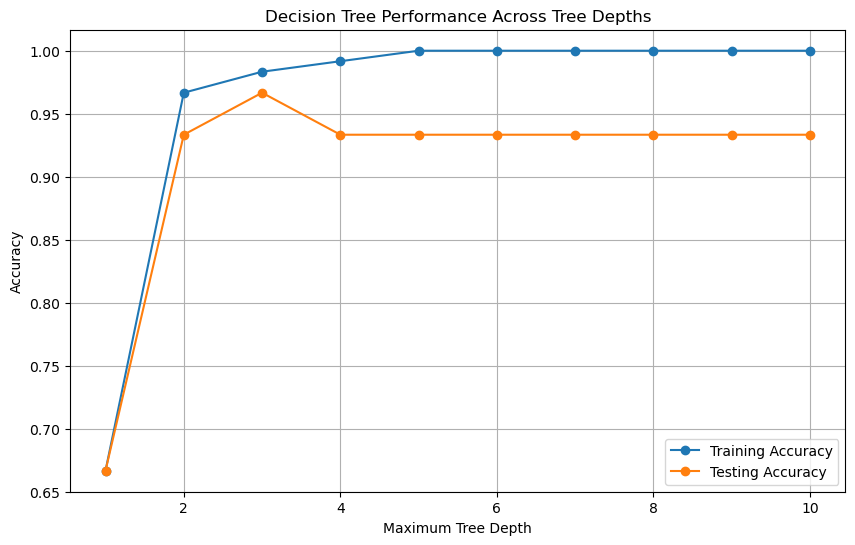

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance Across Tree Depths")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,petal length (cm),0.558568
3,petal width (cm),0.406015
1,sepal width (cm),0.029167
0,sepal length (cm),0.006250


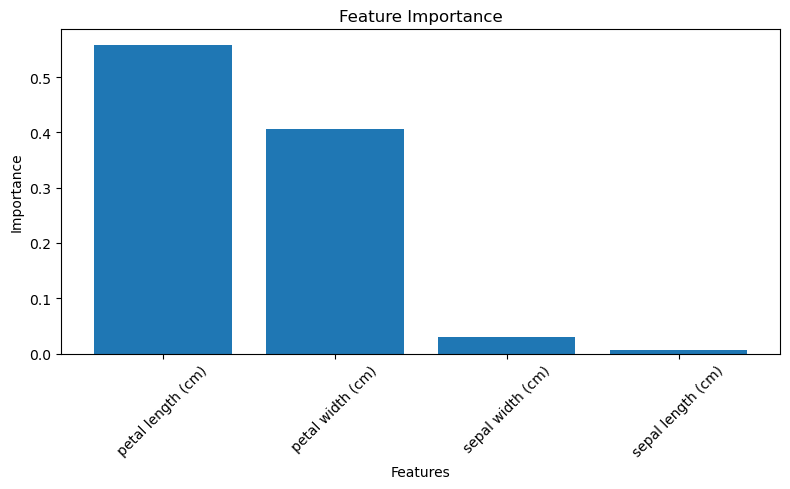

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [22]:
final_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

print("Final Model Accuracy:",
      accuracy_score(y_test, final_predictions))

Final Model Accuracy: 0.9666666666666667


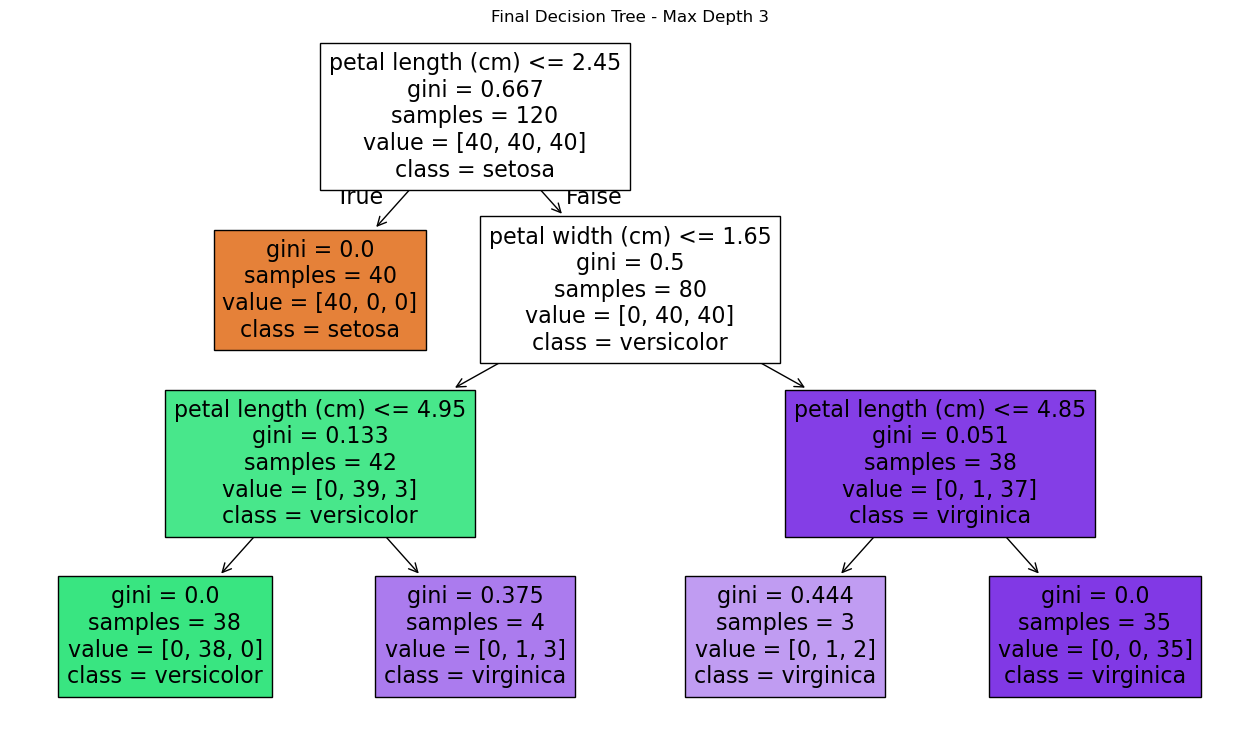

In [23]:
plt.figure(figsize=(16, 9))

plot_tree(
    final_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.title("Final Decision Tree - Max Depth 3")
plt.show()